In [1]:
import pandas as pd
df = pd.read_csv('diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [3]:
df.columns


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [4]:
df['BloodPressure'].mean()

np.float64(69.10546875)

In [5]:
df['Glucose'].max()

np.int64(199)

In [6]:
comparison=df.groupby('Outcome').mean()
print(comparison)

         Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
Outcome                                                                      
0           3.298000  109.980000      68.184000      19.664000   68.792000   
1           4.865672  141.257463      70.824627      22.164179  100.335821   

               BMI  DiabetesPedigreeFunction        Age  
Outcome                                                  
0        30.304200                  0.429734  31.190000  
1        35.142537                  0.550500  37.067164  


In [7]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [8]:
(df['Glucose'] == 0).sum()

np.int64(5)

In [9]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


In [10]:
df['High_BP'] = df['BloodPressure'] > 90

In [11]:
df['High_BP'].value_counts()

High_BP
False    730
True      38
Name: count, dtype: int64

In [12]:
df.to_csv('diabetes_analyzed.csv',index=False)

In [13]:
outliers = df[df['BMI'] > 45]


In [14]:
print(len(outliers))

35


In [15]:
outliers['Glucose'].mean()


np.float64(131.25714285714287)

In [16]:
min_insulin = df['Insulin'].min()
max_insulin = df['Insulin'].max()
print(f"the insulin level ranges from {min_insulin} to {max_insulin}")

the insulin level ranges from 0 to 846


In [17]:
df['Outcome'].value_counts(normalize=True) * 100

Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64

In [18]:
df.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
High_BP                     0.059703
Name: Outcome, dtype: float64

In [19]:
df.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
High_BP                     0.059703
Name: Outcome, dtype: float64

In [20]:
high_risk = df[(df['Age'] > 35) & (df['Glucose'] > 150 )]
                                     

In [21]:
print(len(high_risk))

75


In [22]:
df['Agegroup'] = (df['Age'] // 10) * 10

In [23]:
df.groupby('Agegroup') ['Outcome'].mean()

Agegroup
20    0.212121
30    0.460606
40    0.550847
50    0.596491
60    0.275862
70    0.500000
80    0.000000
Name: Outcome, dtype: float64

In [24]:
df.pivot_table(values='Glucose', index='Agegroup', columns='Outcome', aggfunc='mean')

Outcome,0,1
Agegroup,,
20,106.503205,140.642857
30,113.348315,139.315789
40,109.509434,136.984615
50,123.782609,151.441176
60,131.857143,157.125000
70,119.000000,145.000000
80,134.000000,NaN


In [25]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,High_BP,Agegroup
0,6,148,72,35,0,33.6,0.627,50,1,False,50
1,1,85,66,29,0,26.6,0.351,31,0,False,30
2,8,183,64,0,0,23.3,0.672,32,1,False,30
3,1,89,66,23,94,28.1,0.167,21,0,False,20
4,0,137,40,35,168,43.1,2.288,33,1,False,30


In [26]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,High_BP,Agegroup
0,6,148,72,35,0,33.6,0.627,50,1,False,50
1,1,85,66,29,0,26.6,0.351,31,0,False,30
2,8,183,64,0,0,23.3,0.672,32,1,False,30
3,1,89,66,23,94,28.1,0.167,21,0,False,20
4,0,137,40,35,168,43.1,2.288,33,1,False,30


In [27]:
df.to_csv('diabetes_analyzed.csv', index=False)

In [28]:
age_risk = df.groupby('Agegroup')['Outcome'].mean() * 100
print(age_risk)

Agegroup
20    21.212121
30    46.060606
40    55.084746
50    59.649123
60    27.586207
70    50.000000
80     0.000000
Name: Outcome, dtype: float64


In [29]:
df.pivot_table(values='Outcome', index='High_BP', aggfunc='mean')

,Outcome
High_BP,
False,0.342466
True,0.473684


In [30]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,High_BP,Agegroup
0,6,148,72,35,0,33.6,0.627,50,1,False,50
1,1,85,66,29,0,26.6,0.351,31,0,False,30
2,8,183,64,0,0,23.3,0.672,32,1,False,30
3,1,89,66,23,94,28.1,0.167,21,0,False,20
4,0,137,40,35,168,43.1,2.288,33,1,False,30


In [31]:
%pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

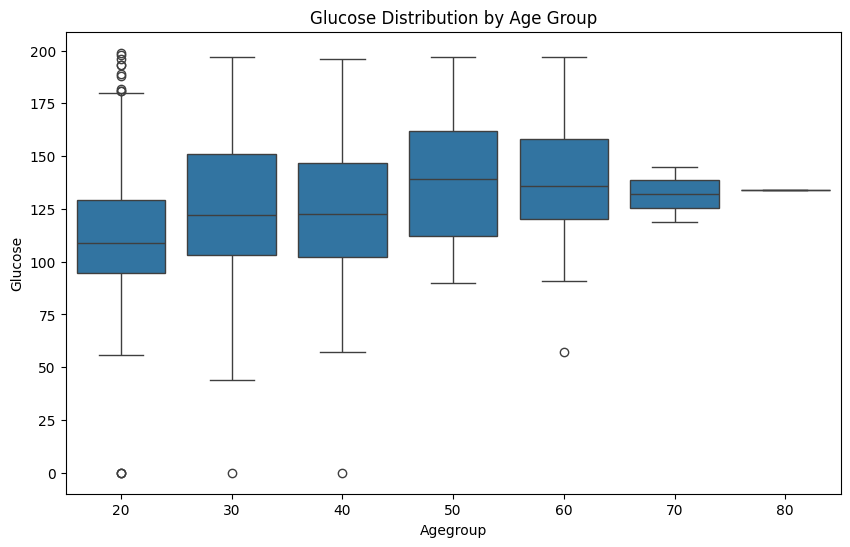

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Agegroup', y='Glucose', data=df)
plt.title('Glucose Distribution by Age Group')
plt.show()

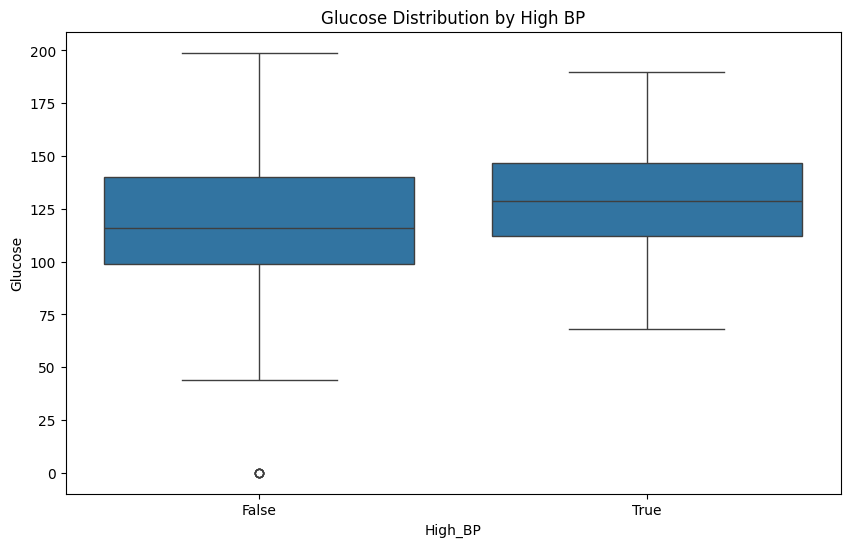

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(x='High_BP', y='Glucose', data=df)
plt.title('Glucose Distribution by High BP')
plt.show()

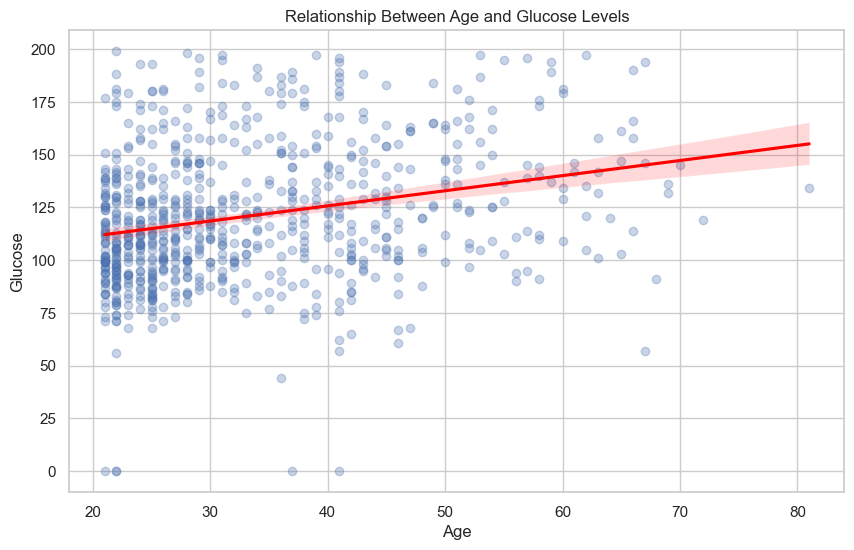

In [35]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Age', y='Glucose', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Relationship Between Age and Glucose Levels')
plt.show()

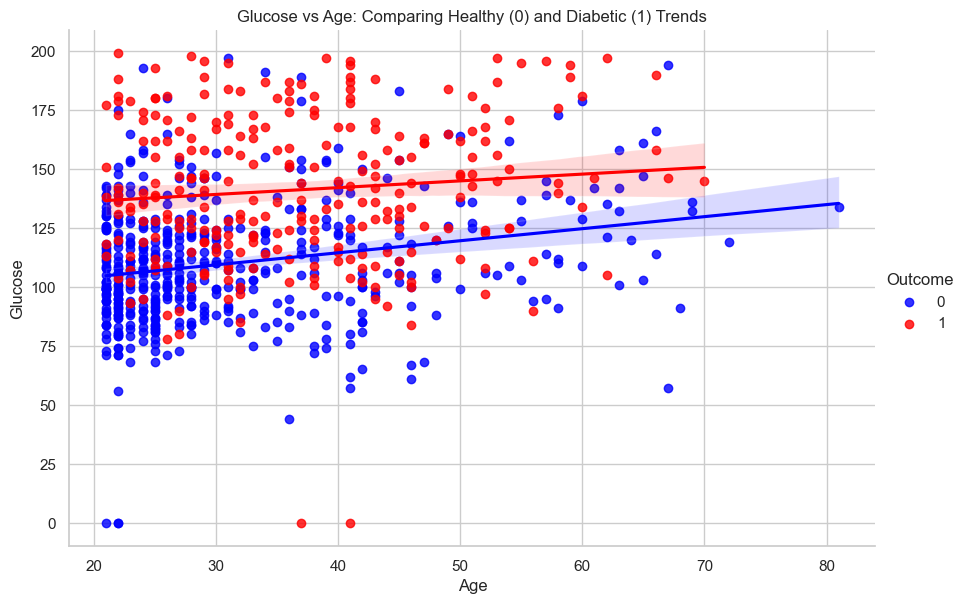

In [36]:
custom_colors = {0: "blue", 1: "red"}
sns.lmplot(data=df, x='Age', y='Glucose', hue='Outcome', 
           palette= custom_colors, aspect=1.5, height=6)
plt.title('Glucose vs Age: Comparing Healthy (0) and Diabetic (1) Trends')
plt.show()



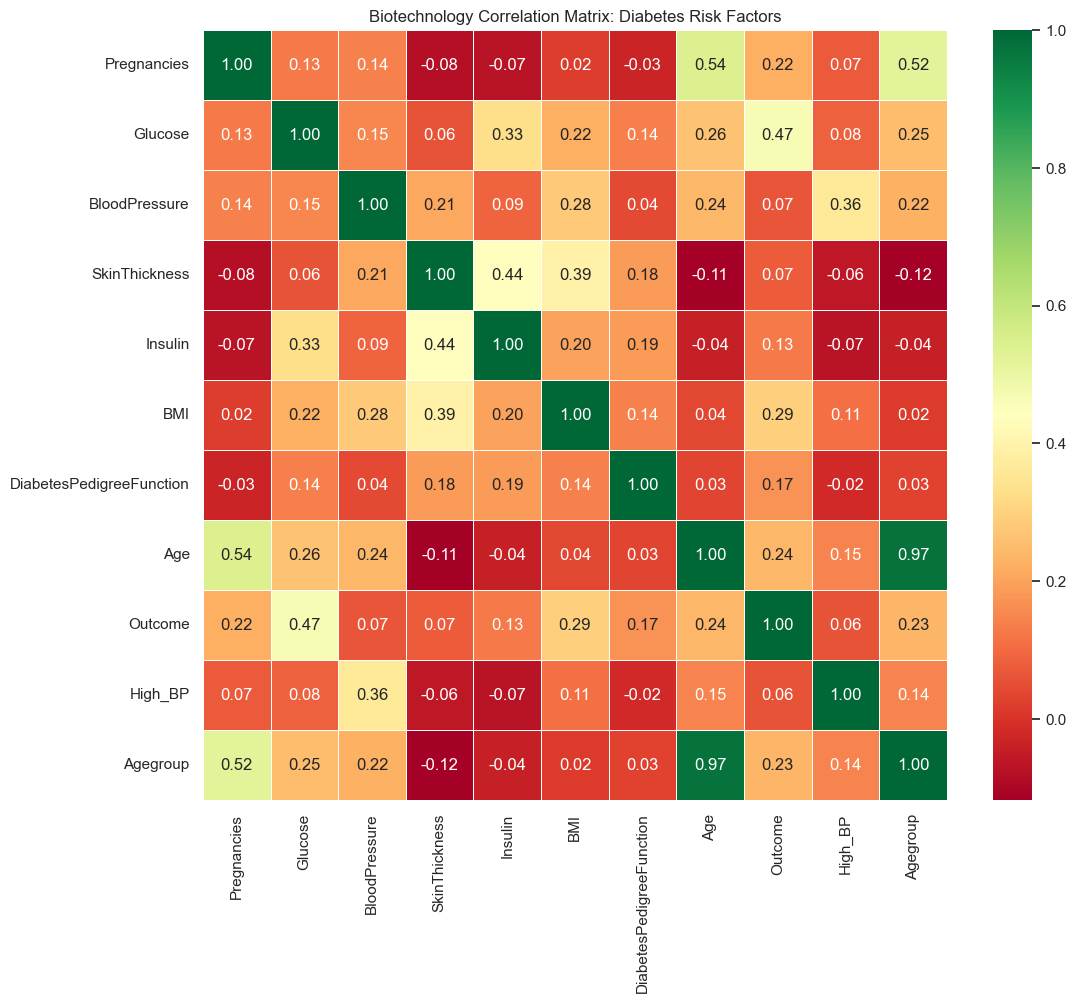

In [37]:
corr_matrix = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Biotechnology Correlation Matrix: Diabetes Risk Factors')
plt.show()